# WFS controls for operation at ALS beamline 5.3.1
walangrizolli@lbl.gov, francisho@lbl.gov, khchan@lbl.gov, awojdyla@lbl.gov

We cleaned up the code, refactoring ophyd classes into nabla.nophyd.
We tried to use the Central tiled server, but somehow we cannot get the data back

We want to: 
+ collect data with various bender settings
+ collect data with various photon energy
+ FrankotChellapize the whole shebang


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from tiled.client import from_uri

#load the api key from env var
import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

# Initialize the Tiled server and client
tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)


## Bender scan at position 13, 9keV
We think we're on row 5 with 7 um shearing grating

In [ ]:
from bluesky.plans import scan

#RE(scan([basler_camera], Obender, -2000, 0, 11))



Transient Scan ID: 2     Time: 2026-03-20 14:12:04
Persistent Unique Scan ID: '2ff913c8-3205-470a-8eed-be37c5fa3bc7'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1483.99152                    |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+------------+
|   seq_num |       time |  bender_um |
+-----------+------------+------------+
|         1 | 14:12:13.5 | -1999.98786 |
|         2 | 14:12:19.5 | -1800.01992 |
|         3 | 14:12:25.0 | -1600.01859 |
|         4 | 14:12:30.5 | -1400.01726 |
|         5 | 14:12:35.8 | -1200.01593 |
|         6 | 14:12:41.3 | -1000.01619 |
|         7 | 14:12:46.8 | -80

('2ff913c8-3205-470a-8eed-be37c5fa3bc7',)

In [5]:
uid = '2ff913c8-3205-470a-8eed-be37c5fa3bc7'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
bends_um = db['primary']['bender_um'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

In [23]:
# scaling parameters
## there's binning in the data
px_m = (2.4e-6)/5*2
grating_freq_cpm = 1/7e-6

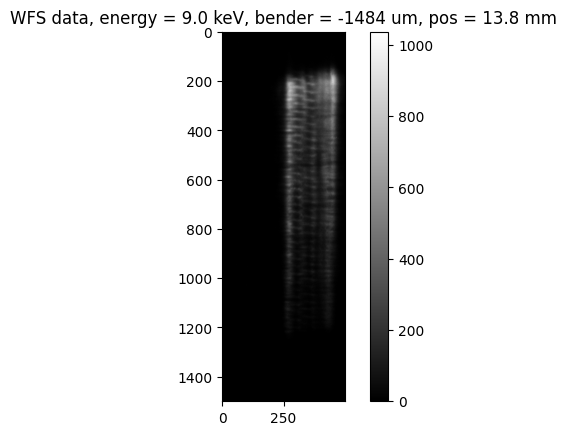

In [10]:
plt.figure()
plt.imshow(images[0,:,1000:1500], cmap='gray')
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (E_eV[0]*1e-3, bender_um[0], wfs_chip_pos_mm[0]))
plt.colorbar()
plt.show()


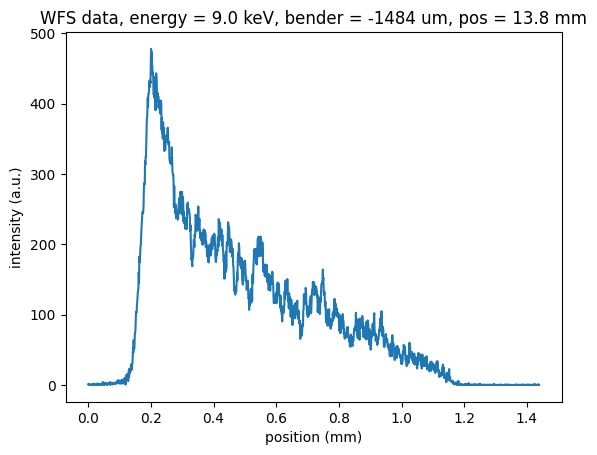

In [20]:
plt.figure()

line_avg = images[0,:,1400:1405].mean(axis=1)
x_m = np.arange(line_avg.size)*px_m
plt.plot(x_m*1e3, line_avg)
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (E_eV[0]*1e-3, bender_um[0], wfs_chip_pos_mm[0]))
plt.xlabel('position (mm)')
plt.ylabel('intensity (a.u.)')
plt.show()

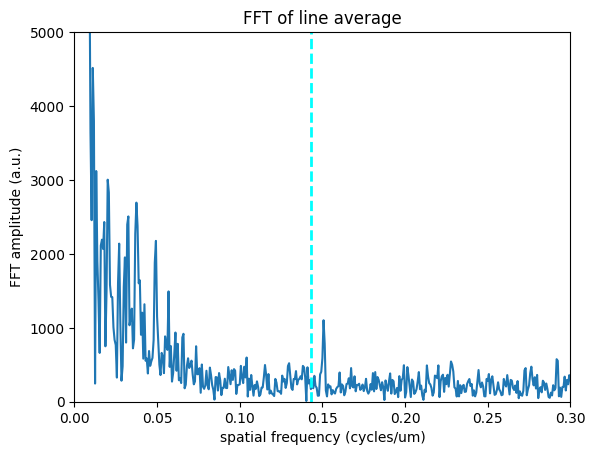

In [30]:
import numpy as np
f_cpm = np.fft.fftshift(np.fft.fftfreq(line_avg.size, d=px_m))
IMG = np.fft.fftshift(np.fft.fft(line_avg))
plt.plot(f_cpm*1e-6, np.abs(IMG))
plt.axvline(grating_freq_cpm * 1e-6, color='cyan', linestyle='--', linewidth=2, label='7um pitch')
plt.xlabel('spatial frequency (cycles/um)')
plt.ylabel('FFT amplitude (a.u.)')
plt.title('FFT of line average')
plt.xlim(0, 0.30)  # focus on positive frequencies
plt.ylim(0, 5000)
plt.show()  

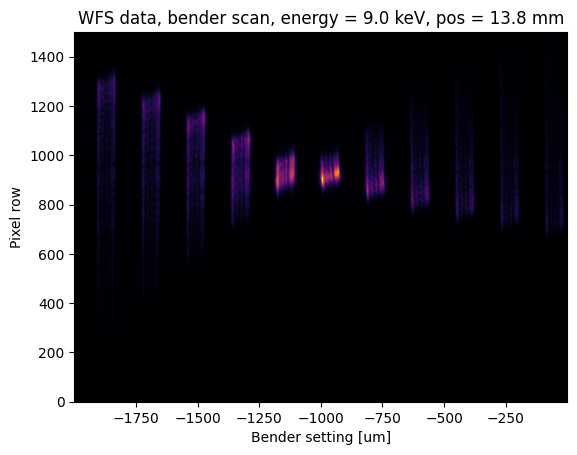

In [7]:
import numpy as np

# Stack the images horizontally
stacked_image = np.hstack(images[:,:,1000:1500])

plt.imshow(stacked_image, cmap='inferno',extent=(bends_um[0], bends_um[-1], 0, stacked_image.shape[0]), origin='upper')
plt.title('Horizontally Stacked Images')
plt.title('WFS data, bender scan, energy = %1.1f keV, pos = %.1f mm' % (E_eV[0]*1e-3, wfs_chip_pos_mm[0]))
plt.xlabel('Bender setting [um]')
plt.ylabel('Pixel row')
plt.show()

## Energy scan 

In [93]:
from bluesky.plans import scan
Obender.move(-1484)
RE(scan([basler_camera], mono_energy, 8000, 9000, 11))



Transient Scan ID: 3     Time: 2026-03-20 14:34:23
Persistent Unique Scan ID: 'eff5f4d9-f29c-424c-a8cc-e77ab64c6b4a'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1483.9931100000001            |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |
+-----------+------------+-----------------------+------------------------+
|         1 | 14:34:41.5 |              8000.184 |                20.7550 |
|         2 | 14:34:45.3 |              8099.982 |                20.5750 |
|         3 | 14

('eff5f4d9-f29c-424c-a8cc-e77ab64c6b4a',)

In [121]:
uid = 'eff5f4d9-f29c-424c-a8cc-e77ab64c6b4a'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
mono_energy_eV = db['primary']['mono_energy_energy_eV'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

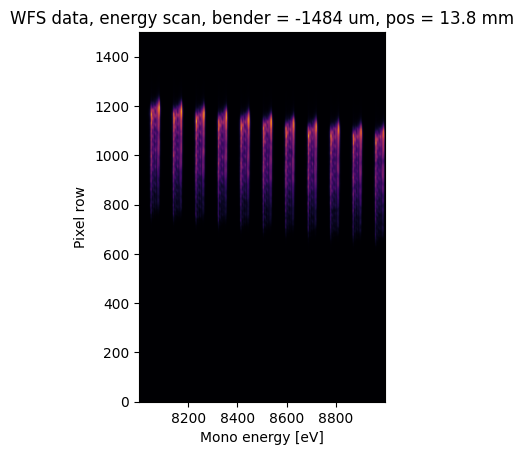

In [ ]:
import numpy as np

# Stack the images horizontally
stacked_image = np.hstack(images[:,:,1000:1500])
plt.imshow(stacked_image, cmap='inferno',extent=(mono_energy_eV[0], mono_energy_eV[-1], 0, stacked_image.shape[0]), origin='upper')
plt.xlabel('Mono energy [eV]')
plt.ylabel('Pixel row')
plt.title('WFS data, energy scan, bender = %.0f um, pos = %.1f mm' % (bender_um[0], wfs_chip_pos_mm[0]))
plt.show()

In [107]:
from bluesky.plans import scan
Obender.move(-1484)
RE(scan([basler_camera], mono_energy, 7000, 10000, 21))



Transient Scan ID: 4     Time: 2026-03-20 14:41:11
Persistent Unique Scan ID: '9f354b67-6a48-43f7-b3f8-72985e90ea21'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1483.9931100000001            |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |
+-----------+------------+-----------------------+------------------------+
|         1 | 14:41:50.9 |              6999.820 |                22.8540 |
|         2 | 14:41:56.4 |              7149.963 |                22.5000 |
|         3 | 14

('9f354b67-6a48-43f7-b3f8-72985e90ea21',)

In [123]:
uid = '9f354b67-6a48-43f7-b3f8-72985e90ea21'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
mono_energy_eV = db['primary']['mono_energy_energy_eV'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

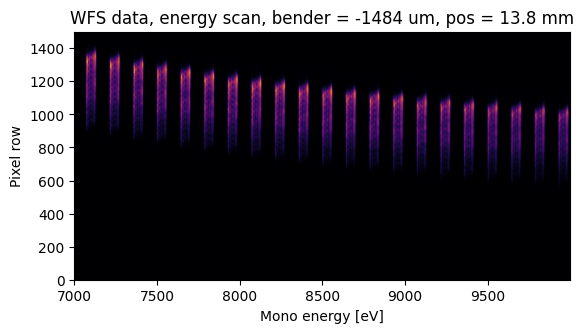

In [124]:
# Stack the images horizontally
stacked_image = np.hstack(images[:,:,1000:1500])
plt.imshow(stacked_image, cmap='inferno',extent=(mono_energy_eV[0], mono_energy_eV[-1], 0, stacked_image.shape[0]), origin='upper')
plt.xlabel('Mono energy [eV]')
plt.ylabel('Pixel row')
plt.title('WFS data, energy scan, bender = %.0f um, pos = %.1f mm' % (bender_um[0], wfs_chip_pos_mm[0]))
plt.show()

In [125]:
from bluesky.plans import scan
Obender.move(-1484)
RE(scan([basler_camera], mono_energy, 5000, 11000, 61))



Transient Scan ID: 5     Time: 2026-03-20 14:55:35
Persistent Unique Scan ID: 'acfd18bf-3ffe-4fa0-a381-2be8e82ca207'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 9999.769788152656              |
|         mono_energy_mono_angle | 17.85                          |
|                      bender_um | -1483.9931100000001            |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |
+-----------+------------+-----------------------+------------------------+
|         1 | 14:57:59.7 |              4999.987 |                29.7410 |
|         2 | 14:58:15.7 |              5100.013 |                29.2580 |
|         3 | 14

('acfd18bf-3ffe-4fa0-a381-2be8e82ca207',)

In [126]:
uid = 'acfd18bf-3ffe-4fa0-a381-2be8e82ca207'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
mono_energy_eV = db['primary']['mono_energy_energy_eV'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

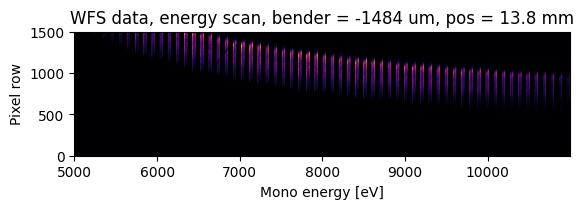

In [127]:
# Stack the images horizontally
stacked_image = np.hstack(images[:,:,1000:1500])
plt.imshow(stacked_image, cmap='inferno',extent=(mono_energy_eV[0], mono_energy_eV[-1], 0, stacked_image.shape[0]), origin='upper')
plt.xlabel('Mono energy [eV]')
plt.ylabel('Pixel row')
plt.title('WFS data, energy scan, bender = %.0f um, pos = %.1f mm' % (bender_um[0], wfs_chip_pos_mm[0]))
plt.show()

In [ ]:
from bluesky.plans import grid_scan
#Obender.move(-1484)
RE(grid_scan([basler_camera], mono_energy, 7000, 10000, 7, Obender, -2000, -1000,6, snake_axes=False))  



Transient Scan ID: 7     Time: 2026-03-20 16:45:47
Persistent Unique Scan ID: '2cb2ab5e-8acc-4a66-abec-63ebab791958'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1500.01713                    |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |  bender_um |
+-----------+------------+-----------------------+------------------------+------------+
|         1 | 16:46:27.2 |              6999.820 |                22.8540 | -1999.98786 |
|         2 | 16:46:33.3 |             

('2cb2ab5e-8acc-4a66-abec-63ebab791958',)

CA.Client.Exception...............................................
    Context: "192.168.10.124:41915"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Tue Mar 24 2026 09:30:37.128617139
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:35637"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Tue Mar 24 2026 14:39:55.919552227
..................................................................
